### a. Appliquer l'algorithme de partitionnement hiérarchique

In [1]:
import warnings

warnings.filterwarnings('ignore')

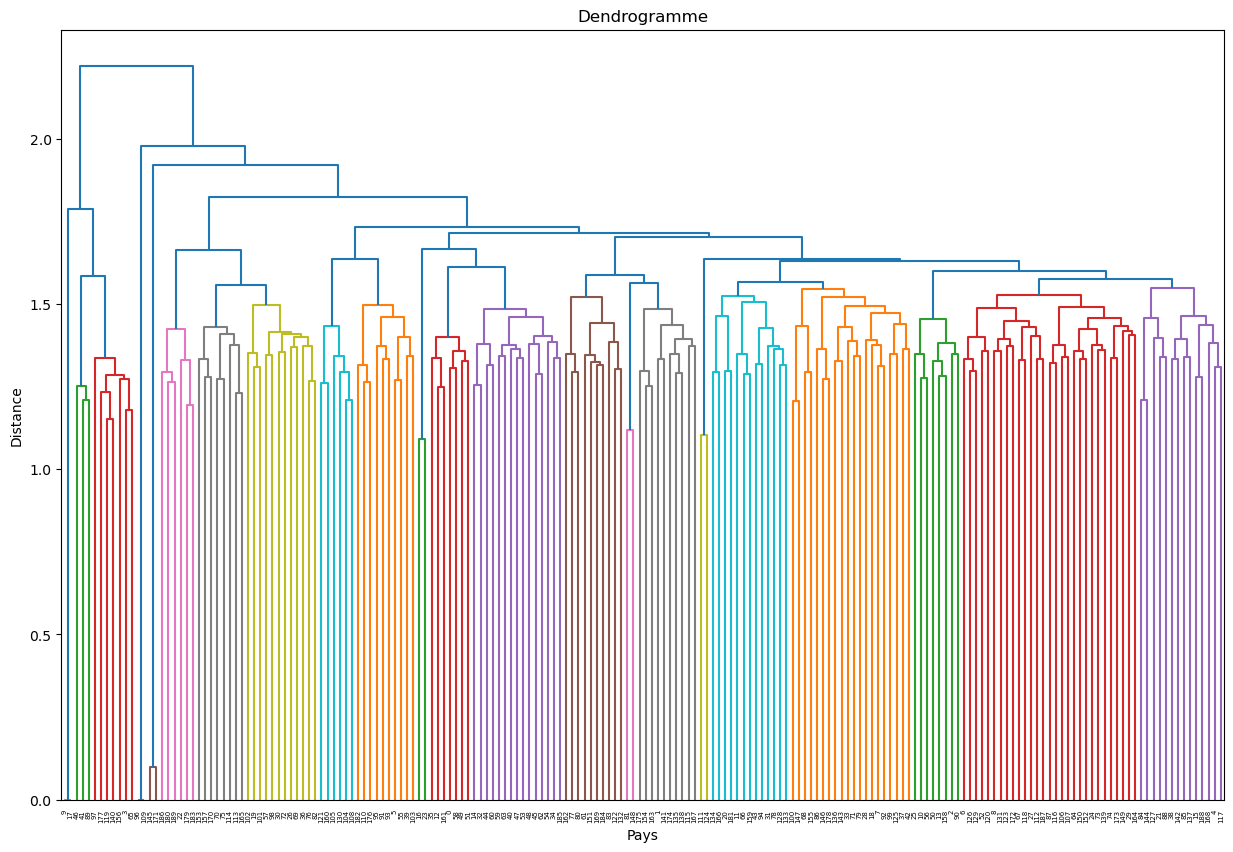

In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Charger les données
df = pd.read_csv('./anthems.csv')

# Nettoyage superficiel
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.strip()
    return text

df['Anthem'] = df['Anthem'].apply(clean_text)

# Vectorisation
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['Anthem'])

# Convertir la matrice sparse en une matrice dense
X_dense = X.toarray()

# Appliquer l'algorithme de partitionnement hiérarchique
hierarchical_clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
hierarchical_clustering.fit(X_dense)

# Tracer le dendrogramme
plt.figure(figsize=(15, 10))
dendrogram(linkage(X_dense, method='ward'))
plt.title('Dendrogramme')
plt.xlabel('Pays')
plt.ylabel('Distance')
plt.show()

### b. Déterminer le nombre optimal de clusters par la méthode du coude
### Nous allons tracer le dendrogramme pour visualiser les distances et déterminer le nombre optimal de clusters.

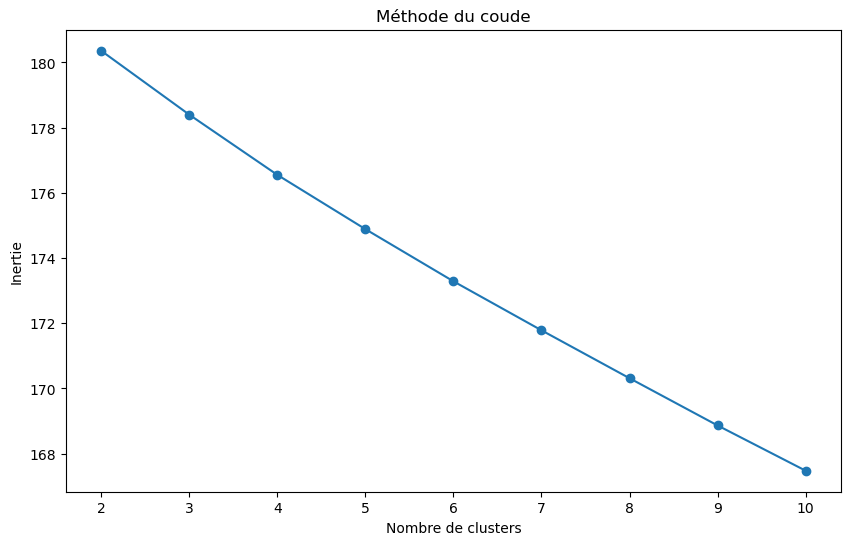

In [3]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# Calculer la matrice de linkage
Z = linkage(X_dense, method='ward')

# Calculer les inerties pour différentes valeurs de k
inertias = []
K = range(2, 11)

for k in K:
    # Créer les clusters
    labels = fcluster(Z, k, criterion='maxclust')
    
    # Calculer l'inertie
    inertia = 0
    for cluster in range(1, k+1):
        cluster_points = X_dense[labels == cluster]
        centroid = cluster_points.mean(axis=0)
        inertia += ((cluster_points - centroid) ** 2).sum()
    
    inertias.append(inertia)

# Tracer la courbe de la méthode du coude
plt.figure(figsize=(10, 6))
plt.plot(K, inertias, marker='o')
plt.title('Méthode du coude')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.show()

### c. Déterminer le nombre optimal de clusters par la méthode silhouette

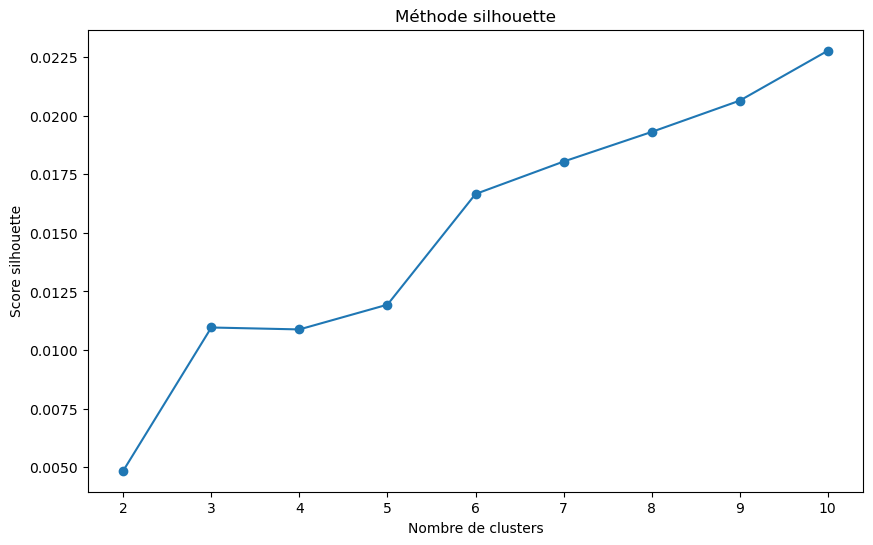

In [4]:
from sklearn.metrics import silhouette_score

# Méthode silhouette
silhouette_scores = []
for k in range(2, 11):
    hierarchical_clustering = AgglomerativeClustering(n_clusters=k)
    labels = hierarchical_clustering.fit_predict(X_dense)
    score = silhouette_score(X_dense, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Méthode silhouette')
plt.xlabel('Nombre de clusters')
plt.ylabel('Score silhouette')
plt.show()

### d. Ajouter au dataset original une variable “cluster”

In [5]:
# Supposons que le nombre optimal de clusters est k=5
optimal_k = 5
hierarchical_clustering = AgglomerativeClustering(n_clusters=optimal_k)
clusters = hierarchical_clustering.fit_predict(X_dense)

# Ajouter les clusters au dataset original
df['cluster'] = clusters

# Sauvegarder le dataframe avec les clusters
df.to_csv('./anthems_with_clusters_hierarchical.csv', index=False)

# Vérifier les premières lignes du dataframe avec les clusters
print(df.head())

      Country Alpha-2 Alpha-3 Continent  \
0     Albania      AL     ALB    Europe   
1     Armenia      AM     ARM    Europe   
2     Austria      AT     AUT    Europe   
3  Azerbaijan      AZ     AZE    Europe   
4     Belarus      BY     BLR    Europe   

                                              Anthem  cluster  
0  around our flag we stand united with one wish ...        1  
1  our fatherland free independent that has for c...        1  
2  land of mountains land by the river land of fi...        1  
3  azerbaijan azerbaijan the glorious fatherland ...        0  
4  we belarusians are peaceful people wholehearte...        1  


### e. Représenter les pays dans le plan engendré par les deux premières composantes principales

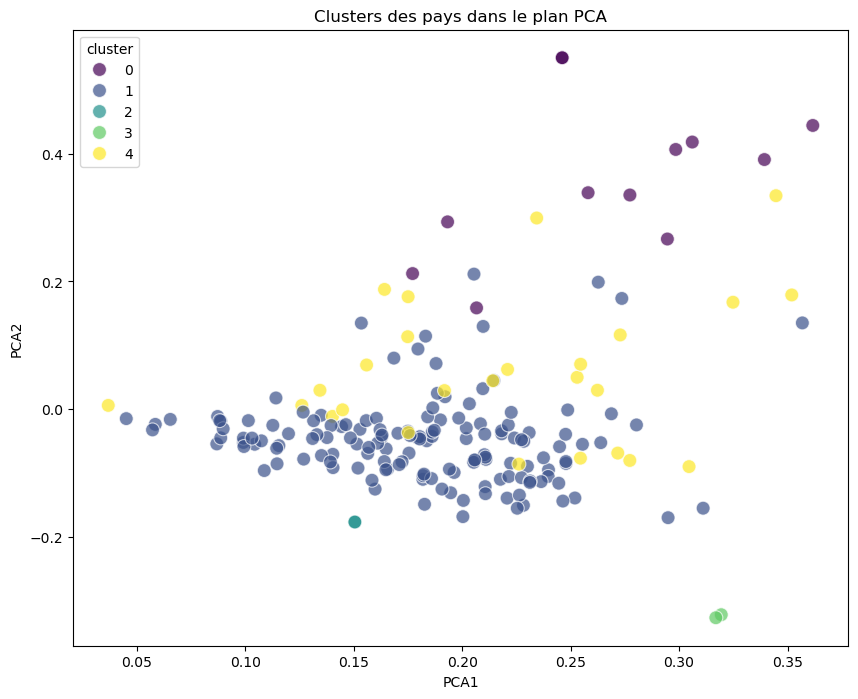

In [6]:
from sklearn.decomposition import TruncatedSVD
import seaborn as sns
import matplotlib.pyplot as plt

# Réduction de dimension avec TruncatedSVD
svd = TruncatedSVD(n_components=2)
components = svd.fit_transform(X_dense)

# Ajouter les composantes principales au dataframe
df['PCA1'] = components[:, 0]
df['PCA2'] = components[:, 1]

# Visualisation des clusters dans le plan PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Clusters des pays dans le plan PCA')
plt.show()

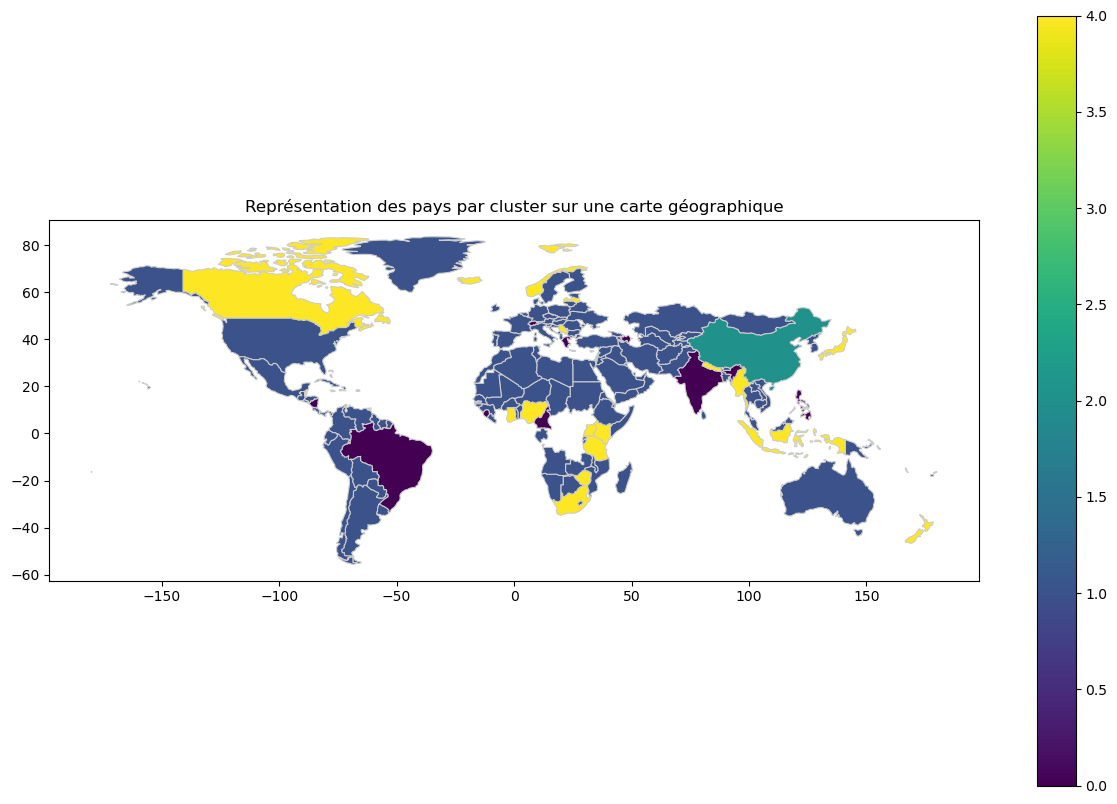

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Charger une carte du monde
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Fusionner avec le dataframe contenant les clusters
merged = world.set_index('name').join(df.set_index('Country'))

# Représenter les pays avec une couleur par cluster
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
merged.plot(column='cluster', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
plt.title('Représentation des pays par cluster sur une carte géographique')
plt.show()

### g. Représenter les mots les plus fréquents dans chaque cluster avec un nuage de mots

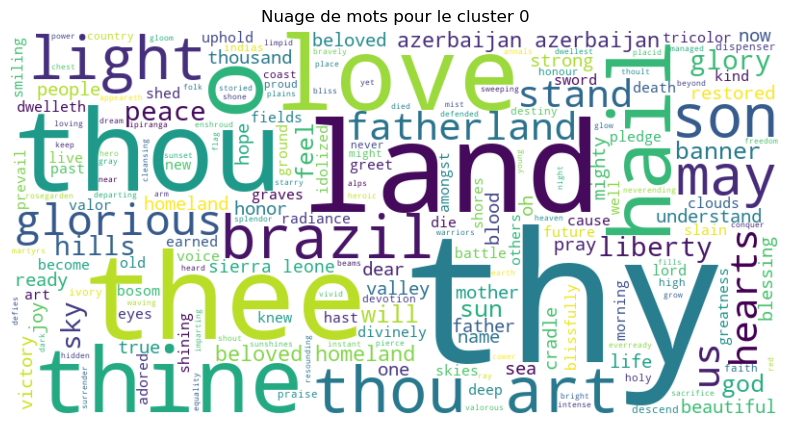

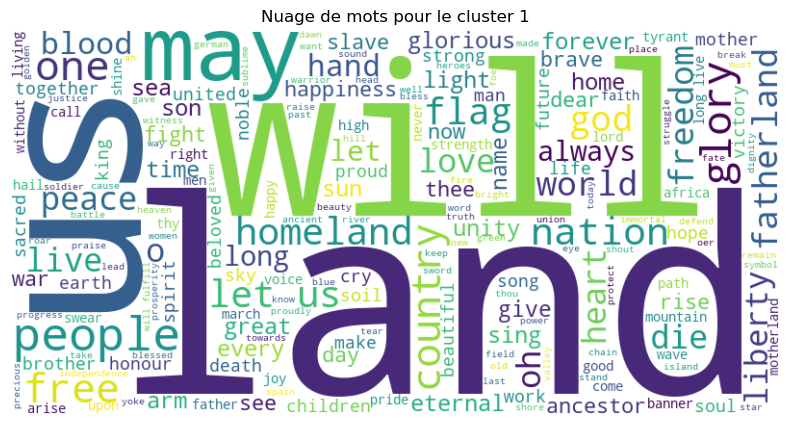

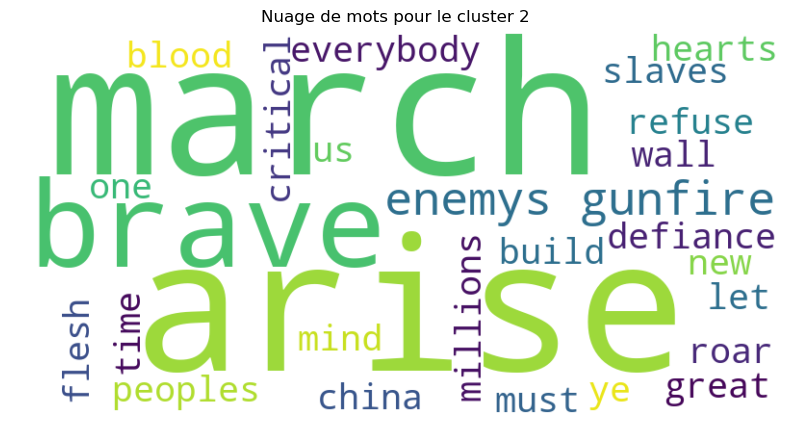

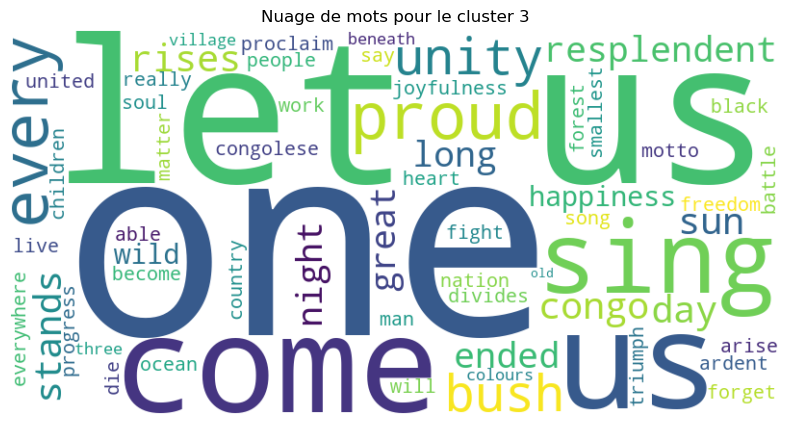

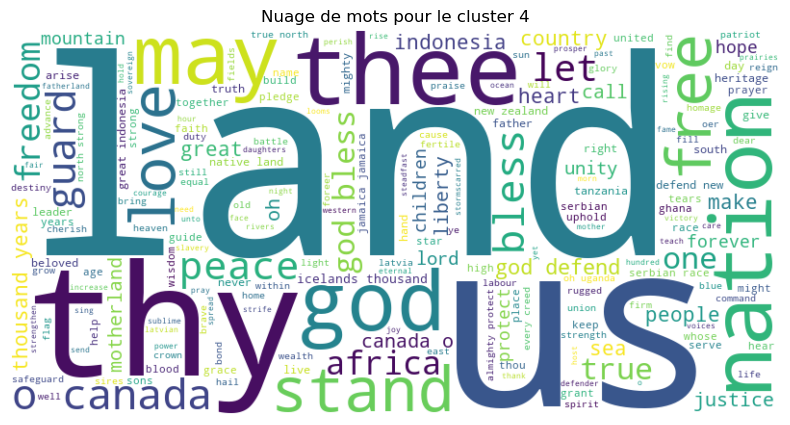

In [8]:
from wordcloud import WordCloud

# Créer des nuages de mots pour chaque cluster
for cluster in range(optimal_k):
    cluster_texts = df[df['cluster'] == cluster]['Anthem'].str.cat(sep=' ')
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(cluster_texts)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nuage de mots pour le cluster {cluster}')
    plt.show()